# HDB Resale Price Regression — Notebook 16: Have Singaporeans Become More Superstitious Over Time?

**Research question:** Has the market's sensitivity to superstition-related variables — lucky 8s in price, unlucky block numbers with 4 — changed over the past 35 years?

**Method:** Replicate Notebook 8's approach (non-overlapping 2-year windows, 1990–2025) but track superstition variable coefficients instead of lease decay. Same base regression specification, same robust standard errors, same normalisation.

**Context:** Model 12 (R² = 0.9365) has two surviving superstition variables: `num_eights_tail` (+$1,707 per trailing 8) and `block_num_eights` (+$3,697 per 8 in block number), both p < 0.001. This notebook tests whether that effect is modern or longstanding — and whether it has strengthened.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from IPython.display import display

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

print('Setup complete.')

Setup complete.


## Load data and derive superstition variables

In [2]:
# Load full historical dataset (975K rows, 1990-2026)
full = pd.read_csv('data/hdb_resale_full.csv', low_memory=False)
full['month'] = pd.to_datetime(full['month'])
full['year'] = full['month'].dt.year
full['remaining_lease_sq'] = full['remaining_lease_years'] ** 2
full['month_str'] = full['month'].dt.strftime('%Y-%m')

# === Price-digit superstition variables ===
price_str = full['resale_price'].astype(int).astype(str)
price_tail = price_str.str[-4:]

full['num_eights_tail'] = price_tail.str.count('8')
full['ends_in_8'] = (full['resale_price'].astype(int) % 10 == 8).astype(int)
full['ends_888'] = price_str.str.endswith('888').astype(int)
full['price_has_168'] = price_str.str.contains('168').astype(int)

# === Block-number superstition ===
full['block_has_4'] = full['block'].astype(str).str.contains('4').astype(int)

# === Floor superstition: EXCLUDED ===
# HDB data gives storey RANGES (e.g. "04 TO 06", "13 TO 15"), not exact floor
# assignments. A flat in the "04 TO 06" band has a 1-in-3 chance of being on
# floor 4 — equally likely to be on floor 5 or 6. This is too imprecise to
# test floor-level superstition. We would need exact unit-level data (which
# data.gov.sg does not provide) to properly test whether floor 4 or floor 13
# carries a price penalty.

print(f'Full dataset: {len(full):,} rows')
print(f'Date range: {full["month"].min().strftime("%Y-%m")} to {full["month"].max().strftime("%Y-%m")}')
print(f'\n=== Superstition variable prevalence (full dataset) ===')
for var in ['num_eights_tail', 'ends_in_8', 'ends_888', 'price_has_168', 'block_has_4']:
    if full[var].max() <= 1:
        pct = full[var].mean() * 100
        print(f'  {var:20s}: {full[var].sum():>8,} ({pct:.1f}%)')
    else:
        print(f'  {var:20s}: mean={full[var].mean():.3f}, max={full[var].max()}')

# Define non-overlapping 2-year windows
windows = []
for start in range(1990, 2026, 2):
    end = start + 1
    label = f'{start}-{str(end)[-2:]}'
    windows.append((start, end, label))

print(f'\n{len(windows)} windows: {windows[0][2]} to {windows[-1][2]}')

Full dataset: 976,261 rows
Date range: 1990-01 to 2026-04

=== Superstition variable prevalence (full dataset) ===
  num_eights_tail     : mean=0.205, max=4
  ends_in_8           :   21,288 (2.2%)
  ends_888            :   18,751 (1.9%)
  price_has_168       :    3,847 (0.4%)
  block_has_4         :  273,548 (28.0%)

18 windows: 1990-91 to 2024-25


## Prevalence trends (descriptive, no regression)

Before running regressions, look at how common each superstition-linked behaviour is in each period. The prevalence of 888-ending prices is itself the strongest evidence of changing seller psychology — no model needed.

In [3]:
# Compute prevalence of each superstition variable by 2-year window
prev_rows = []
for start, end, label in windows:
    w = full[(full['year'] >= start) & (full['year'] <= end)]
    if len(w) < 100:
        continue
    row = {
        'period': label,
        'midpoint': (start + end) / 2,
        'n': len(w),
        'mean_price': w['resale_price'].mean(),
        'pct_ends_in_8': w['ends_in_8'].mean() * 100,
        'pct_ends_888': w['ends_888'].mean() * 100,
        'pct_price_has_168': w['price_has_168'].mean() * 100,
        'n_ends_888': w['ends_888'].sum(),
        'pct_block_has_4': w['block_has_4'].mean() * 100,
    }
    prev_rows.append(row)

prev = pd.DataFrame(prev_rows)

print('=== Prevalence by period ===')
print(f'{"Period":>8s}  {"N":>8s}  {"Mean $":>10s}  {"ends_8%":>8s}  {"888%":>8s}  '
      f'{"168%":>8s}  {"blk4%":>8s}  {"N(888)":>8s}')
print('-' * 80)
for _, r in prev.iterrows():
    print(f'{r["period"]:>8s}  {r["n"]:>8,.0f}  ${r["mean_price"]:>9,.0f}  '
          f'{r["pct_ends_in_8"]:>7.1f}%  {r["pct_ends_888"]:>7.2f}%  '
          f'{r["pct_price_has_168"]:>7.2f}%  {r["pct_block_has_4"]:>7.1f}%  '
          f'{r["n_ends_888"]:>8,.0f}')

=== Prevalence by period ===
  Period         N      Mean $   ends_8%      888%      168%     blk4%    N(888)
--------------------------------------------------------------------------------
 1990-91    25,360  $   70,876      0.0%     0.02%     0.11%     26.4%         5
 1992-93    32,619  $  111,273      0.0%     0.03%     0.25%     26.4%        10
 1994-95    53,662  $  192,708      0.1%     0.07%     0.48%     29.2%        40
 1996-97    66,678  $  293,063      0.2%     0.17%     0.58%     30.4%       111
 1998-99   108,877  $  254,806      0.3%     0.20%     0.61%     30.4%       216
 2000-01    72,917  $  250,444      0.6%     0.38%     0.63%     29.0%       275
 2002-03    65,101  $  233,279      0.9%     0.62%     0.65%     27.8%       403
 2004-05    59,157  $  234,659      1.1%     0.77%     1.08%     27.4%       454
 2006-07    54,409  $  249,071      1.0%     0.68%     0.82%     26.9%       368
 2008-09    57,744  $  328,107      1.5%     1.16%     0.14%     27.0%       669

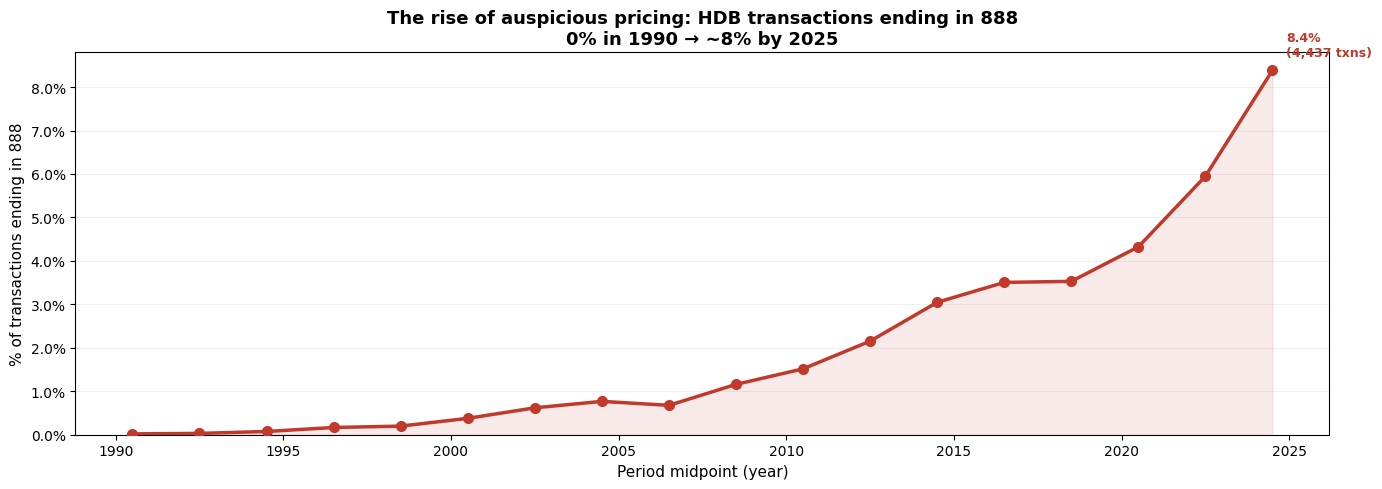

Saved to data/superstition_888_prevalence.png


In [4]:
# Chart 1: 888-ending price prevalence — THE HEADLINE CHART
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(prev['midpoint'], prev['pct_ends_888'], 'o-', color='#c0392b',
        linewidth=2.5, markersize=7, zorder=3)
ax.fill_between(prev['midpoint'], 0, prev['pct_ends_888'],
                alpha=0.1, color='#c0392b')

ax.set_xlabel('Period midpoint (year)', fontsize=11)
ax.set_ylabel('% of transactions ending in 888', fontsize=11)
ax.set_title('The rise of auspicious pricing: HDB transactions ending in 888\n'
             '0% in 1990 \u2192 ~8% by 2025',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.1f}%'))
ax.grid(axis='y', alpha=0.2)
ax.set_ylim(bottom=0)

last = prev.iloc[-1]
ax.annotate(f'{last["pct_ends_888"]:.1f}%\n({last["n_ends_888"]:,.0f} txns)',
            xy=(last['midpoint'], last['pct_ends_888']),
            xytext=(10, 10), textcoords='offset points',
            fontsize=9, color='#c0392b', fontweight='bold')

plt.tight_layout()
plt.savefig('data/superstition_888_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/superstition_888_prevalence.png')

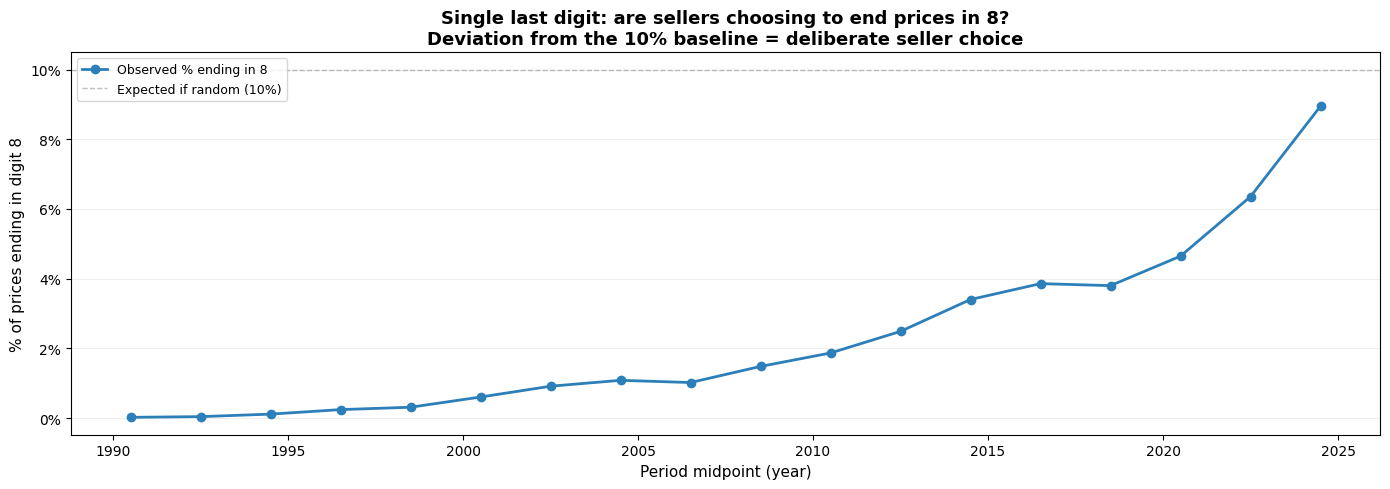

In [5]:
# Chart 2: last-digit-8 prevalence vs expected 10% baseline
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(prev['midpoint'], prev['pct_ends_in_8'], 'o-', color='#2c7fb8',
        linewidth=2, markersize=6, zorder=3, label='Observed % ending in 8')
ax.axhline(y=10, color='gray', linestyle='--', alpha=0.5, linewidth=1,
           label='Expected if random (10%)')

ax.set_xlabel('Period midpoint (year)', fontsize=11)
ax.set_ylabel('% of prices ending in digit 8', fontsize=11)
ax.set_title('Single last digit: are sellers choosing to end prices in 8?\n'
             'Deviation from the 10% baseline = deliberate seller choice',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}%'))
ax.grid(axis='y', alpha=0.2)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

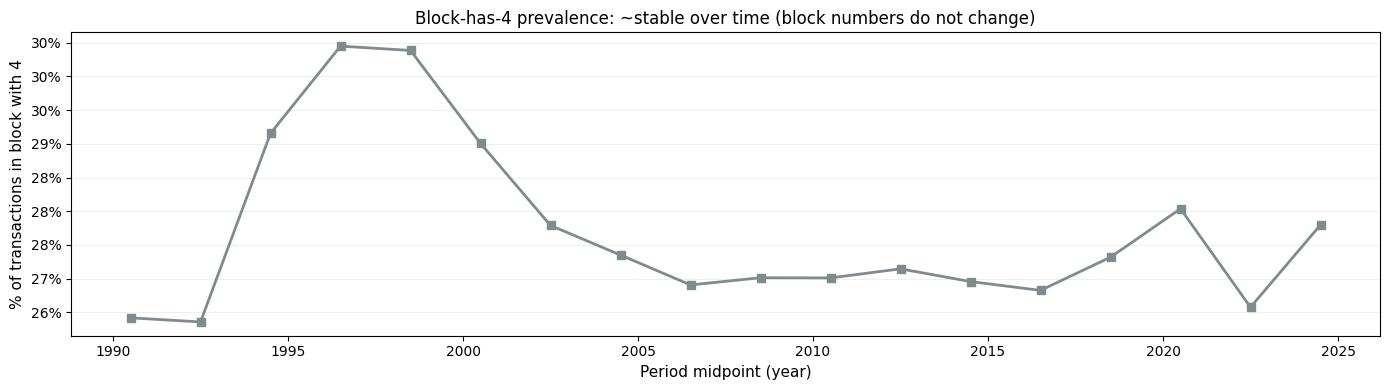

In [6]:
# Chart 3: block_has_4 prevalence (sanity check — should be ~stable)
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(prev['midpoint'], prev['pct_block_has_4'], 's-', color='#7f8c8d',
        linewidth=2, markersize=6, zorder=3)

ax.set_xlabel('Period midpoint (year)', fontsize=11)
ax.set_ylabel('% of transactions in block with 4', fontsize=11)
ax.set_title('Block-has-4 prevalence: ~stable over time (block numbers do not change)',
             fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}%'))
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

### The price-digit artifact

**Why `num_eights_tail` is not perfectly comparable across eras:**

In the 1990s, HDB prices were mostly 5 digits ($80,000–$200,000). The \"last 4 digits\" of $88,000 is `8000` — the 8 is the leading significant digit, not a deliberate trailing auspicious digit. By the 2020s, prices are 6 digits ($400,000–$800,000), and trailing 8s in patterns like `$X88,888` are genuinely deliberate seller choices.

**Mitigation:** We track THREE measures:
1. `num_eights_tail` — the Model 12 variable (primary, but cross-era caveat applies)
2. `ends_in_8` — single last digit, less affected by price magnitude
3. `ends_888` prevalence — pure behavioural trend, no regression needed

All regression coefficients are normalised by period mean price for cross-era comparison.

### Why floor superstition variables are excluded

The HDB dataset gives storey **ranges** (e.g. \"04 TO 06\", \"13 TO 15\"), not exact floor assignments. A flat in the \"04 TO 06\" band could be on floor 4, 5, or 6 — we have no way to tell. This means any \"has_floor_4\" variable is really \"storey range includes 4\", which captures floors 4, 5, AND 6. Same problem for floor 13: the \"13 TO 15\" band lumps floors 13, 14, and 15 together.

With only a 1-in-3 chance that the flat is actually on the superstitious floor, the variable is too noisy to reliably test floor-level superstition. We would need exact unit-level data (which data.gov.sg does not provide) to properly test this.

## Regression: superstition coefficients across 18 windows

**Specification:** Same controls as Notebook 8 (town, flat type, size, storey, remaining lease linear + quadratic, flat model, month fixed effects), plus superstition variables.

No distance variables (MRT, CBD, hawker, etc.) — those require geocoding unavailable for historical data. Town fixed effects absorb most geographic variation.

In [7]:
super_vars = ['num_eights_tail', 'ends_in_8', 'block_has_4']

formula = ('resale_price ~ C(town) + C(flat_type) + floor_area_sqm + storey_mid + '
           'remaining_lease_years + remaining_lease_sq + C(flat_model_grouped) + C(month_str) + '
           'num_eights_tail + ends_in_8 + block_has_4')

results = []
for start, end, label in windows:
    w = full[(full['year'] >= start) & (full['year'] <= end)].copy()
    
    if len(w) < 500:
        print(f'{label}: only {len(w)} rows, skipped')
        continue
    
    mc = w['flat_model'].value_counts()
    rare = mc[mc < 50].index
    w['flat_model_grouped'] = w['flat_model'].apply(lambda x: 'Other' if x in rare else x)
    
    try:
        model = smf.ols(formula, data=w).fit(cov_type='HC1')
        mean_price = w['resale_price'].mean()
        
        row = {
            'period': label, 'midpoint': (start + end) / 2,
            'n': len(w), 'mean_price': mean_price, 'r_squared': model.rsquared,
        }
        for var in super_vars:
            if var in model.params:
                row[f'{var}_coef'] = model.params[var]
                row[f'{var}_se'] = model.bse[var]
                row[f'{var}_pval'] = model.pvalues[var]
                row[f'{var}_pct'] = (model.params[var] / mean_price) * 100
                row[f'{var}_se_pct'] = (model.bse[var] / mean_price) * 100
            else:
                for s in ['_coef','_se','_pval','_pct','_se_pct']:
                    row[f'{var}{s}'] = np.nan
        results.append(row)
        
        parts = [f'{label}:  n={len(w):>6,}  R\u00b2={model.rsquared:.3f}']
        for var in super_vars:
            if var in model.params:
                sig = '*' if model.pvalues[var] < 0.05 else ' '
                parts.append(f'{var}={model.params[var]:>+8,.0f}{sig}')
        print('  '.join(parts))
    except Exception as e:
        print(f'{label}: FAILED \u2014 {e}')

res = pd.DataFrame(results)
print(f'\nCompleted {len(res)} regressions.')

1990-91:  n=25,360  R²=0.917  num_eights_tail=  +1,444*  ends_in_8=  +2,408   block_has_4=    -617*


1992-93:  n=32,619  R²=0.898  num_eights_tail=    +886   ends_in_8= +21,560*  block_has_4=    -731*


1994-95:  n=53,662  R²=0.949  num_eights_tail=  +2,539*  ends_in_8=  +1,489   block_has_4=    +115 


1996-97:  n=66,678  R²=0.960  num_eights_tail=  +1,057*  ends_in_8=  +1,248   block_has_4=    -396 


1998-99:  n=108,877  R²=0.962  num_eights_tail=    +974*  ends_in_8=  +3,338*  block_has_4=    +640*


...

2016-17:  n=39,882  R²=0.866  num_eights_tail=  +3,619*  ends_in_8=  -8,671*  block_has_4=  -7,139*


2018-19:  n=43,747  R²=0.866  num_eights_tail=  +3,036*  ends_in_8=  -3,104   block_has_4=  -7,077*


2020-21:  n=52,420  R²=0.883  num_eights_tail=  +3,031*  ends_in_8=  -4,593   block_has_4= -10,506*


2022-23:  n=52,474  R²=0.889  num_eights_tail=  +4,358*  ends_in_8=  -9,345*  block_has_4=  -8,301*


2024-25:  n=52,918  R²=0.884  num_eights_tail=  +4,430*  ends_in_8=  -9,393*  block_has_4= -13,249*

Completed 18 regressions.


## Results table

In [8]:
print('=== Superstition coefficients by period (raw $, * = p < 0.05) ===')
print(f'{"Period":>8s}  {"N":>7s}  {"R\u00b2":>5s}  {"Mean $":>9s}  '
      f'{"8s_tail":>10s}  {"ends_8":>10s}  {"blk_4":>10s}')
print('-' * 70)
for _, r in res.iterrows():
    parts = [f'{r["period"]:>8s}  {r["n"]:>7,.0f}  {r["r_squared"]:.3f}  ${r["mean_price"]:>8,.0f}']
    for var in super_vars:
        coef = r.get(f'{var}_coef', np.nan)
        pval = r.get(f'{var}_pval', np.nan)
        if pd.isna(coef):
            parts.append(f'{"\u2014":>10s}')
        else:
            sig = '*' if pval < 0.05 else ' '
            parts.append(f'{coef:>+9,.0f}{sig}')
    print('  '.join(parts))

print(f'\n=== Same coefficients as % of mean price ===')
print(f'{"Period":>8s}  {"8s_tail%":>10s}  {"ends_8%":>10s}  {"blk_4%":>10s}')
print('-' * 45)
for _, r in res.iterrows():
    parts = [f'{r["period"]:>8s}']
    for var in super_vars:
        pct = r.get(f'{var}_pct', np.nan)
        pval = r.get(f'{var}_pval', np.nan)
        if pd.isna(pct):
            parts.append(f'{"\u2014":>10s}')
        else:
            sig = '*' if pval < 0.05 else ' '
            parts.append(f'{pct:>+8.2f}%{sig}')
    print('  '.join(parts))

=== Superstition coefficients by period (raw $, * = p < 0.05) ===
  Period        N     R²     Mean $     8s_tail      ends_8       blk_4
----------------------------------------------------------------------
 1990-91   25,360  0.917  $  70,876     +1,444*     +2,408        -617*
 1992-93   32,619  0.898  $ 111,273       +886     +21,560*       -731*
 1994-95   53,662  0.949  $ 192,708     +2,539*     +1,489        +115 
 1996-97   66,678  0.960  $ 293,063     +1,057*     +1,248        -396 
 1998-99  108,877  0.962  $ 254,806       +974*     +3,338*       +640*
 2000-01   72,917  0.948  $ 250,444     +1,182*     +2,549        +149 
 2002-03   65,101  0.928  $ 233,279       +258      +2,197        -851*
 2004-05   59,157  0.869  $ 234,659       -868*     +3,620*     -1,446*
 2006-07   54,409  0.871  $ 249,071     +1,590*       +663      -2,165*
 2008-09   57,744  0.862  $ 328,107     +1,001*     +3,424      -3,873*
 2010-11   57,135  0.870  $ 397,661     +1,029*     +1,420      -4,010*

## Does superstition explain MORE of price variance now than before?

The key test: run the base model (town, flat type, size, floor, lease, flat model, month) **without** superstition variables, then add them. If the R² improvement (ΔR²) has grown over time, superstition is becoming a bigger factor in the market.

**ANOVA F-test** — tests whether the improvement from adding superstition variables is statistically significant in each window. A smaller p-value means the superstition variables collectively explain a more reliable chunk of variance.

In [9]:
base_formula = ('resale_price ~ C(town) + C(flat_type) + floor_area_sqm + storey_mid + '
                'remaining_lease_years + remaining_lease_sq + C(flat_model_grouped) + C(month_str)')

full_formula = (base_formula + ' + num_eights_tail + ends_in_8 + block_has_4')

delta_rows = []
for start, end, label in windows:
    w = full[(full['year'] >= start) & (full['year'] <= end)].copy()
    if len(w) < 500:
        continue
    mc = w['flat_model'].value_counts()
    rare = mc[mc < 50].index
    w['flat_model_grouped'] = w['flat_model'].apply(lambda x: 'Other' if x in rare else x)

    try:
        m_base = smf.ols(base_formula, data=w).fit()
        m_full = smf.ols(full_formula, data=w).fit()

        r2_base = m_base.rsquared
        r2_full = m_full.rsquared
        delta_r2 = r2_full - r2_base

        k_extra = m_full.df_model - m_base.df_model
        ss_base = m_base.ssr
        ss_full = m_full.ssr
        f_stat = ((ss_base - ss_full) / k_extra) / (ss_full / m_full.df_resid)
        f_pval = 1 - stats.f.cdf(f_stat, k_extra, m_full.df_resid)

        delta_rows.append({
            'period': label, 'midpoint': (start + end) / 2, 'n': len(w),
            'r2_base': r2_base, 'r2_full': r2_full,
            'delta_r2': delta_r2, 'delta_r2_pct': delta_r2 * 100,
            'f_stat': f_stat, 'f_pval': f_pval,
        })
        sig = '***' if f_pval < 0.001 else '**' if f_pval < 0.01 else '*' if f_pval < 0.05 else ''
        print(f'{label}:  R\u00b2_base={r2_base:.4f}  R\u00b2_full={r2_full:.4f}  '
              f'\u0394R\u00b2={delta_r2:.5f} ({delta_r2*100:.3f}%)  '
              f'F={f_stat:.1f}  p={f_pval:.2e} {sig}')
    except Exception as e:
        print(f'{label}: FAILED \u2014 {e}')

delta = pd.DataFrame(delta_rows)
print(f'\nCompleted {len(delta)} base vs full comparisons.')

1990-91:  R²_base=0.9172  R²_full=0.9173  ΔR²=0.00013 (0.013%)  F=13.4  p=1.01e-08 ***


1992-93:  R²_base=0.8983  R²_full=0.8983  ΔR²=0.00007 (0.007%)  F=7.3  p=6.52e-05 ***


1994-95:  R²_base=0.9486  R²_full=0.9487  ΔR²=0.00007 (0.007%)  F=25.8  p=1.11e-16 ***


1996-97:  R²_base=0.9596  R²_full=0.9596  ΔR²=0.00001 (0.001%)  F=6.8  p=1.44e-04 ***


1998-99:  R²_base=0.9620  R²_full=0.9621  ΔR²=0.00003 (0.003%)  F=24.9  p=4.44e-16 ***


...

2016-17:  R²_base=0.8655  R²_full=0.8661  ΔR²=0.00055 (0.055%)  F=54.8  p=1.11e-16 ***


2018-19:  R²_base=0.8653  R²_full=0.8658  ΔR²=0.00049 (0.049%)  F=53.3  p=1.11e-16 ***


2020-21:  R²_base=0.8817  R²_full=0.8826  ΔR²=0.00087 (0.087%)  F=129.6  p=1.11e-16 ***


2022-23:  R²_base=0.8880  R²_full=0.8886  ΔR²=0.00056 (0.056%)  F=88.4  p=1.11e-16 ***


2024-25:  R²_base=0.8832  R²_full=0.8842  ΔR²=0.00097 (0.097%)  F=147.9  p=1.11e-16 ***

Completed 18 base vs full comparisons.


/var/folders/7h/fxll2jhj3s9dl0hn4k_ff6v00000gn/T/ipykernel_40666/4117764959.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


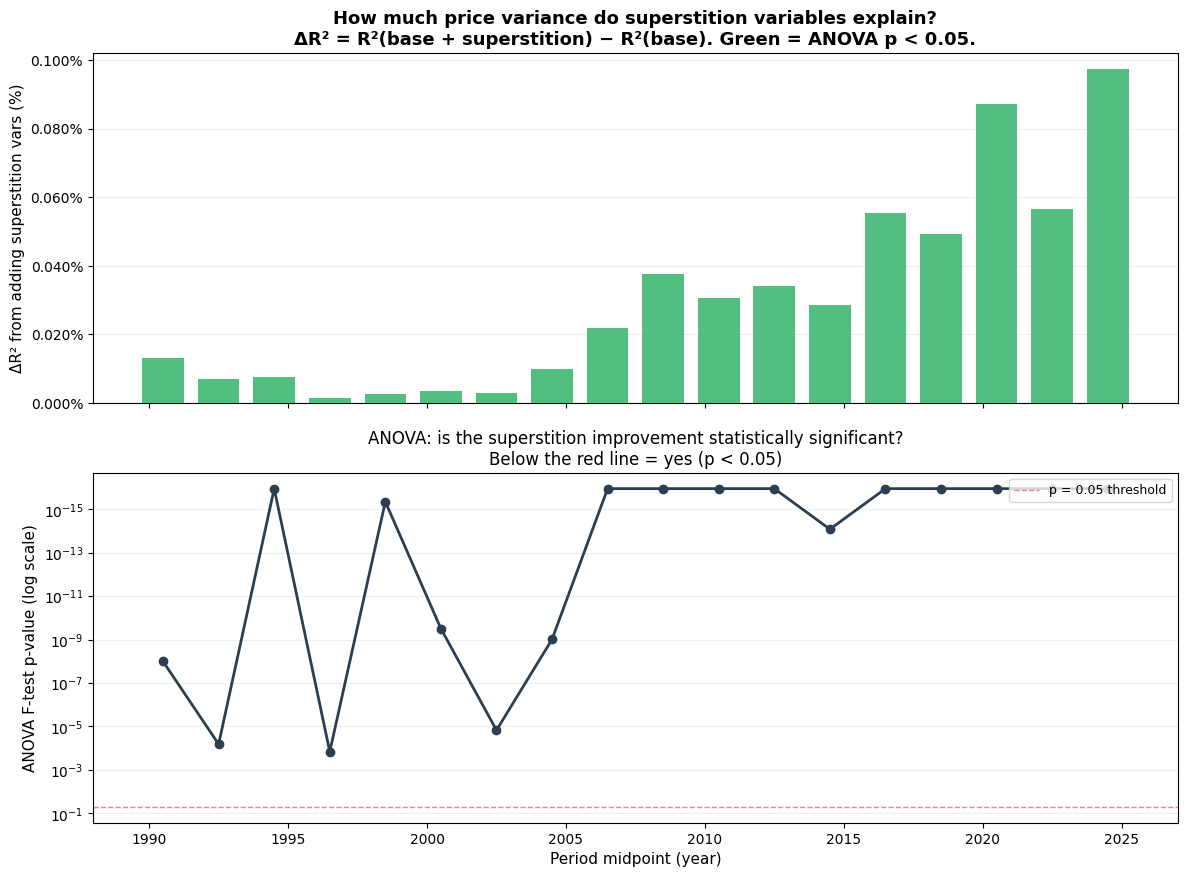

ΔR² range: 0.0012% to 0.0973%
First period (1990-91): ΔR² = 0.0131%, F = 13.4, p = 1.01e-08
Last period  (2024-25): ΔR² = 0.0973%, F = 147.9, p = 1.11e-16

Superstition significantly improves the model in 18/18 windows


In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True,
                                gridspec_kw={'hspace': 0.2})

ax1.bar(delta['midpoint'], delta['delta_r2_pct'], width=1.5,
        color=['#27ae60' if p < 0.05 else '#bdc3c7' for p in delta['f_pval']],
        alpha=0.8, zorder=3)
ax1.set_ylabel('\u0394R\u00b2 from adding superstition vars (%)', fontsize=11)
ax1.set_title('How much price variance do superstition variables explain?\n'
              '\u0394R\u00b2 = R\u00b2(base + superstition) \u2212 R\u00b2(base). Green = ANOVA p < 0.05.',
              fontsize=13, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.3f}%'))
ax1.grid(axis='y', alpha=0.2)

ax2.semilogy(delta['midpoint'], delta['f_pval'], 'o-', color='#2c3e50',
             linewidth=2, markersize=6, zorder=3)
ax2.axhline(y=0.05, color='red', linestyle='--', alpha=0.5, linewidth=1,
            label='p = 0.05 threshold')
ax2.set_xlabel('Period midpoint (year)', fontsize=11)
ax2.set_ylabel('ANOVA F-test p-value (log scale)', fontsize=11)
ax2.set_title('ANOVA: is the superstition improvement statistically significant?\n'
              'Below the red line = yes (p < 0.05)', fontsize=12)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(axis='y', alpha=0.2)
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('data/superstition_delta_r2.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\u0394R\u00b2 range: {delta["delta_r2_pct"].min():.4f}% to {delta["delta_r2_pct"].max():.4f}%')
print(f'First period ({delta.iloc[0]["period"]}): \u0394R\u00b2 = {delta.iloc[0]["delta_r2_pct"]:.4f}%, F = {delta.iloc[0]["f_stat"]:.1f}, p = {delta.iloc[0]["f_pval"]:.2e}')
print(f'Last period  ({delta.iloc[-1]["period"]}): \u0394R\u00b2 = {delta.iloc[-1]["delta_r2_pct"]:.4f}%, F = {delta.iloc[-1]["f_stat"]:.1f}, p = {delta.iloc[-1]["f_pval"]:.2e}')
sig_count = (delta['f_pval'] < 0.05).sum()
print(f'\nSuperstition significantly improves the model in {sig_count}/{len(delta)} windows')

## Individual ΔR²: which superstition variable is driving the growth?

The collective ΔR² above shows that superstition as a whole matters more now. But is that driven by the lucky-8 premium, the block-4 penalty, or both?

Here we add each superstition variable **one at a time** to the base model and measure how much R² improves. This tells us each variable's individual contribution.

In [11]:
# Individual ΔR² for each superstition variable
indiv_vars = ['num_eights_tail', 'ends_in_8', 'block_has_4']
indiv_labels = {'num_eights_tail': 'Trailing 8s', 'ends_in_8': 'Last digit = 8', 'block_has_4': 'Block has 4'}

indiv_rows = []
for start, end, label in windows:
    w = full[(full['year'] >= start) & (full['year'] <= end)].copy()
    if len(w) < 500:
        continue
    mc = w['flat_model'].value_counts()
    rare = mc[mc < 50].index
    w['flat_model_grouped'] = w['flat_model'].apply(lambda x: 'Other' if x in rare else x)

    m_base = smf.ols(base_formula, data=w).fit()
    r2_base = m_base.rsquared

    row = {'period': label, 'midpoint': (start + end) / 2, 'n': len(w), 'r2_base': r2_base}
    for var in indiv_vars:
        f_indiv = base_formula + ' + ' + var
        m_indiv = smf.ols(f_indiv, data=w).fit()
        dr2 = m_indiv.rsquared - r2_base
        row[f'{var}_dr2'] = dr2 * 100
        # F-test for single variable
        ss_base = m_base.ssr
        ss_indiv = m_indiv.ssr
        f_stat = ((ss_base - ss_indiv) / 1) / (ss_indiv / m_indiv.df_resid)
        f_pval = 1 - stats.f.cdf(f_stat, 1, m_indiv.df_resid)
        row[f'{var}_f'] = f_stat
        row[f'{var}_p'] = f_pval
    indiv_rows.append(row)

indiv = pd.DataFrame(indiv_rows)

# Print table
print('=== Individual \u0394R\u00b2: each variable added alone to the base model ===')
print(f'{"Period":>8s}  {"Trailing 8s":>14s}  {"Last digit=8":>14s}  {"Block has 4":>14s}')
print('-' * 58)
for _, r in indiv.iterrows():
    parts = [f'{r["period"]:>8s}']
    for var in indiv_vars:
        dr2 = r[f'{var}_dr2']
        sig = '*' if r[f'{var}_p'] < 0.05 else ' '
        parts.append(f'{dr2:>12.4f}%{sig}')
    print('  '.join(parts))

=== Individual ΔR²: each variable added alone to the base model ===
  Period     Trailing 8s    Last digit=8     Block has 4
----------------------------------------------------------
 1990-91        0.0096%*        0.0005%         0.0034%*
 1992-93        0.0021%*        0.0040%*        0.0017%*
 1994-95        0.0074%*        0.0007%*        0.0000% 
 1996-97        0.0010%*        0.0002%*        0.0002% 
 1998-99        0.0017%*        0.0009%*        0.0007%*
 2000-01        0.0031%*        0.0017%*        0.0000% 
 2002-03        0.0007%*        0.0009%*        0.0017%*
 2004-05        0.0005%         0.0004%         0.0077%*
 2006-07        0.0087%*        0.0036%*        0.0132%*
 2008-09        0.0066%*        0.0061%*        0.0302%*
 2010-11        0.0041%*        0.0030%*        0.0265%*
 2012-13        0.0045%*        0.0034%*        0.0296%*
 2014-15        0.0044%*        0.0012%         0.0228%*
 2016-17        0.0060%*        0.0010%         0.0456%*
 2018-19        0.

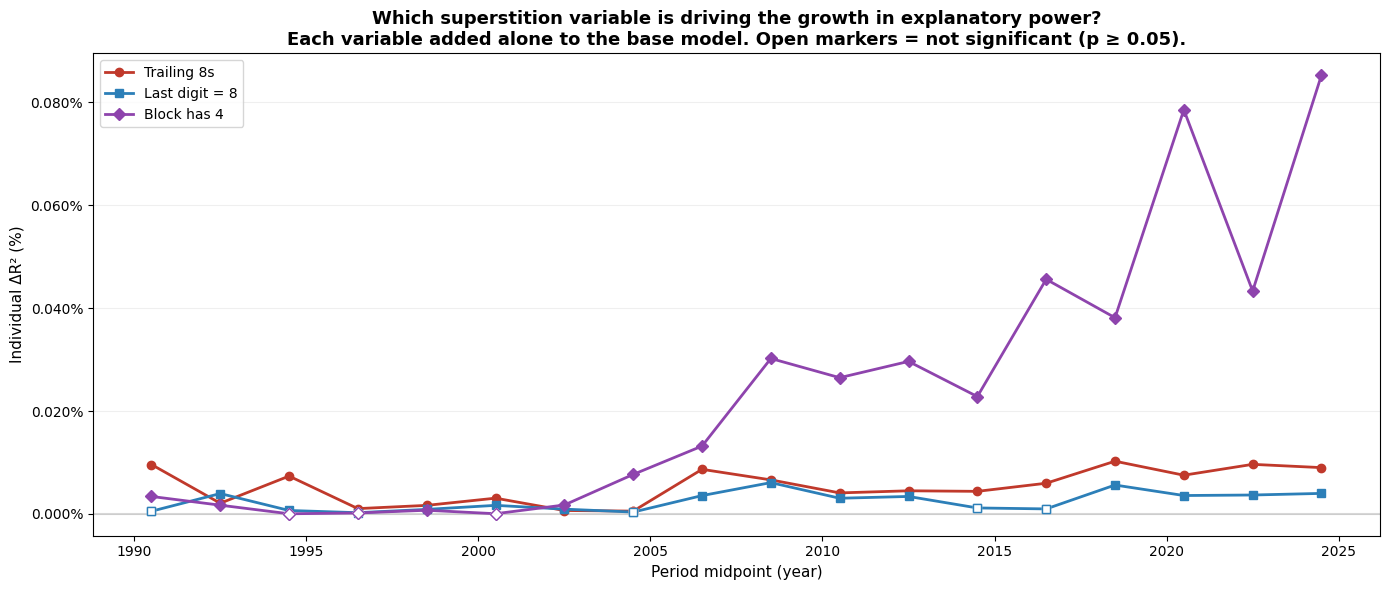

First vs last window:
  Trailing 8s    : 0.0096% → 0.0090%  (0.9x)
  Last digit = 8 : 0.0005% → 0.0040%  (7.7x)
  Block has 4    : 0.0034% → 0.0853%  (25.1x)


In [12]:
# Chart: individual ΔR² over time
fig, ax = plt.subplots(figsize=(14, 6))

colors = {'num_eights_tail': '#c0392b', 'ends_in_8': '#2c7fb8', 'block_has_4': '#8e44ad'}
markers = {'num_eights_tail': 'o', 'ends_in_8': 's', 'block_has_4': 'D'}

for var in indiv_vars:
    ax.plot(indiv['midpoint'], indiv[f'{var}_dr2'], f'{markers[var]}-',
            color=colors[var], linewidth=2, markersize=6, zorder=3,
            label=indiv_labels[var])
    # Open circles for non-significant
    for _, r in indiv.iterrows():
        if r[f'{var}_p'] >= 0.05:
            ax.plot(r['midpoint'], r[f'{var}_dr2'], markers[var],
                    color='white', markersize=6, zorder=4)
            ax.plot(r['midpoint'], r[f'{var}_dr2'], markers[var],
                    color=colors[var], markersize=6, zorder=4, markerfacecolor='none', linewidth=1.5)

ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Period midpoint (year)', fontsize=11)
ax.set_ylabel('Individual \u0394R\u00b2 (%)', fontsize=11)
ax.set_title('Which superstition variable is driving the growth in explanatory power?\n'
             'Each variable added alone to the base model. Open markers = not significant (p \u2265 0.05).',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.3f}%'))
ax.grid(axis='y', alpha=0.2)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('data/superstition_individual_delta_r2.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print('First vs last window:')
for var in indiv_vars:
    first_v = indiv.iloc[0][f'{var}_dr2']
    last_v = indiv.iloc[-1][f'{var}_dr2']
    ratio = last_v / first_v if first_v > 0.0001 else float('inf')
    print(f'  {indiv_labels[var]:15s}: {first_v:.4f}% \u2192 {last_v:.4f}%  ({ratio:.1f}x)')

## Lucky 8 over time — the main story

`num_eights_tail` is one of two superstition variables that survived Model 12's full gauntlet (LAD regression, Cook's D, interaction terms). Has it always been significant, or is it a modern phenomenon?

/var/folders/7h/fxll2jhj3s9dl0hn4k_ff6v00000gn/T/ipykernel_40666/145314854.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


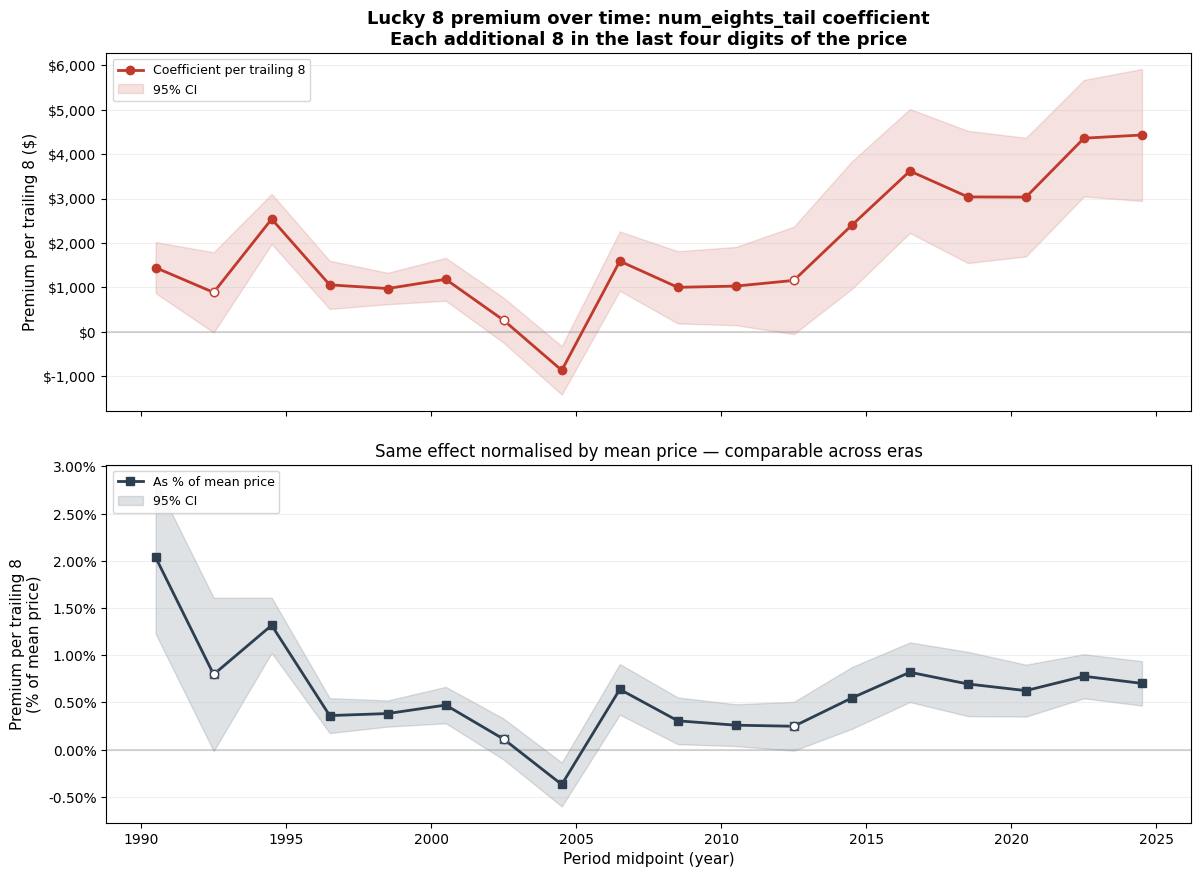

Open circles = not significant at p < 0.05


In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True,
                                gridspec_kw={'hspace': 0.15})

ax1.plot(res['midpoint'], res['num_eights_tail_coef'], 'o-', color='#c0392b',
         linewidth=2, markersize=6, zorder=3, label='Coefficient per trailing 8')
ax1.fill_between(res['midpoint'],
                  res['num_eights_tail_coef'] - 1.96 * res['num_eights_tail_se'],
                  res['num_eights_tail_coef'] + 1.96 * res['num_eights_tail_se'],
                  alpha=0.15, color='#c0392b', label='95% CI')
ax1.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax1.set_ylabel('Premium per trailing 8 ($)', fontsize=11)
ax1.set_title('Lucky 8 premium over time: num_eights_tail coefficient\n'
              'Each additional 8 in the last four digits of the price',
              fontsize=13, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax1.grid(axis='y', alpha=0.2)
ax1.legend(loc='upper left', fontsize=9)
for _, r in res.iterrows():
    if r['num_eights_tail_pval'] >= 0.05:
        ax1.plot(r['midpoint'], r['num_eights_tail_coef'], 'o',
                 color='white', markersize=6, zorder=4)
        ax1.plot(r['midpoint'], r['num_eights_tail_coef'], 'o',
                 color='#c0392b', markersize=6, zorder=4, markerfacecolor='none', linewidth=1.5)

ax2.plot(res['midpoint'], res['num_eights_tail_pct'], 's-', color='#2c3e50',
         linewidth=2, markersize=6, zorder=3, label='As % of mean price')
ax2.fill_between(res['midpoint'],
                  res['num_eights_tail_pct'] - 1.96 * res['num_eights_tail_se_pct'],
                  res['num_eights_tail_pct'] + 1.96 * res['num_eights_tail_se_pct'],
                  alpha=0.15, color='#2c3e50', label='95% CI')
ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax2.set_xlabel('Period midpoint (year)', fontsize=11)
ax2.set_ylabel('Premium per trailing 8\n(% of mean price)', fontsize=11)
ax2.set_title('Same effect normalised by mean price \u2014 comparable across eras', fontsize=12)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.2f}%'))
ax2.grid(axis='y', alpha=0.2)
ax2.legend(loc='upper left', fontsize=9)
for _, r in res.iterrows():
    if r['num_eights_tail_pval'] >= 0.05:
        ax2.plot(r['midpoint'], r['num_eights_tail_pct'], 'o',
                 color='white', markersize=6, zorder=4)
        ax2.plot(r['midpoint'], r['num_eights_tail_pct'], 'o',
                 color='#2c3e50', markersize=6, zorder=4, markerfacecolor='none', linewidth=1.5)

plt.tight_layout()
plt.savefig('data/superstition_lucky8_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Open circles = not significant at p < 0.05')

## Block-4 discount over time

Model 12 dropped `block_has_4` because ~60% of the discount was confounded with town×storey interactions. But the historical model here has no interaction terms — the confound is constant across eras, so *changes* in the coefficient still reflect changing market attitudes toward blocks with 4 in the number.

/var/folders/7h/fxll2jhj3s9dl0hn4k_ff6v00000gn/T/ipykernel_40666/113869422.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


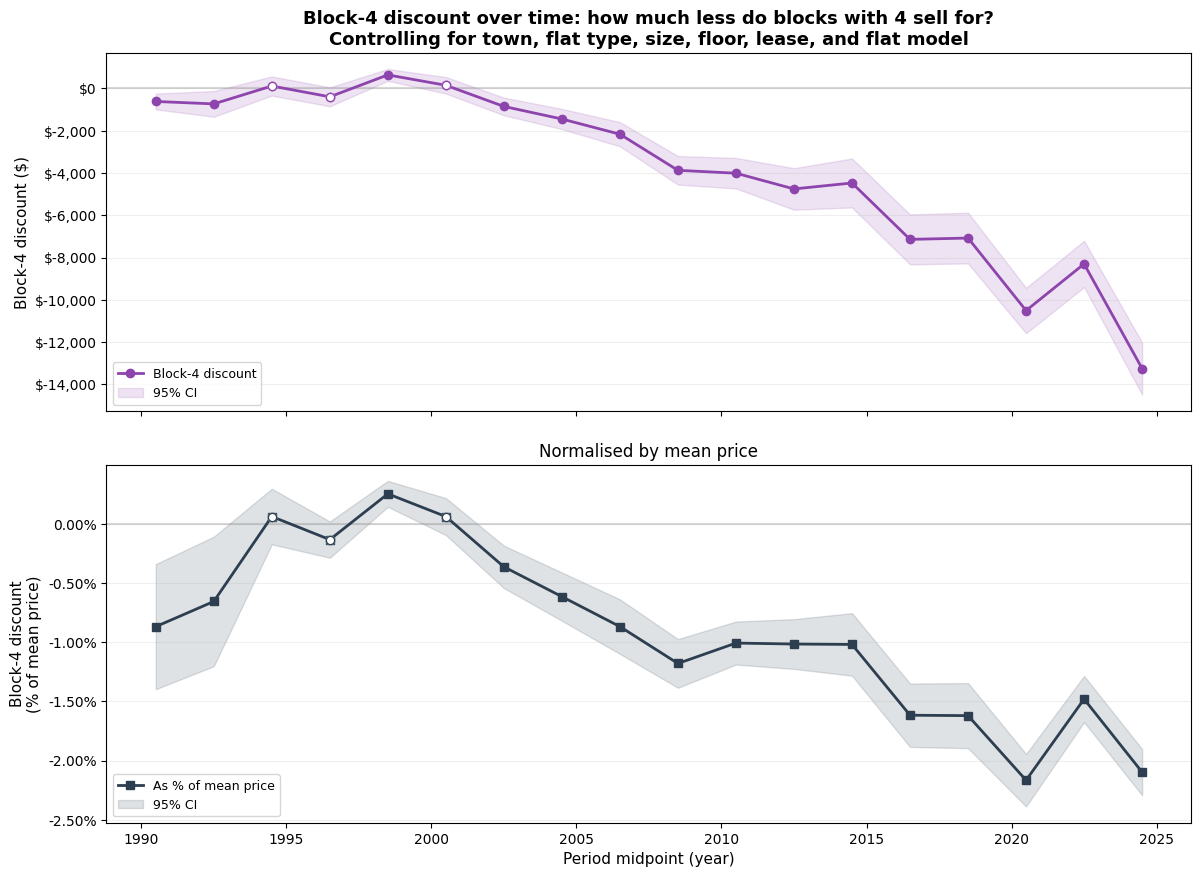

Open circles = not significant at p < 0.05


In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True,
                                gridspec_kw={'hspace': 0.15})

ax1.plot(res['midpoint'], res['block_has_4_coef'], 'o-', color='#8e44ad',
         linewidth=2, markersize=6, zorder=3, label='Block-4 discount')
ax1.fill_between(res['midpoint'],
                  res['block_has_4_coef'] - 1.96 * res['block_has_4_se'],
                  res['block_has_4_coef'] + 1.96 * res['block_has_4_se'],
                  alpha=0.15, color='#8e44ad', label='95% CI')
ax1.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax1.set_ylabel('Block-4 discount ($)', fontsize=11)
ax1.set_title('Block-4 discount over time: how much less do blocks with 4 sell for?\n'
              'Controlling for town, flat type, size, floor, lease, and flat model',
              fontsize=13, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax1.grid(axis='y', alpha=0.2)
ax1.legend(loc='lower left', fontsize=9)
for _, r in res.iterrows():
    if r['block_has_4_pval'] >= 0.05:
        ax1.plot(r['midpoint'], r['block_has_4_coef'], 'o',
                 color='white', markersize=6, zorder=4)
        ax1.plot(r['midpoint'], r['block_has_4_coef'], 'o',
                 color='#8e44ad', markersize=6, zorder=4, markerfacecolor='none', linewidth=1.5)

ax2.plot(res['midpoint'], res['block_has_4_pct'], 's-', color='#2c3e50',
         linewidth=2, markersize=6, zorder=3, label='As % of mean price')
ax2.fill_between(res['midpoint'],
                  res['block_has_4_pct'] - 1.96 * res['block_has_4_se_pct'],
                  res['block_has_4_pct'] + 1.96 * res['block_has_4_se_pct'],
                  alpha=0.15, color='#2c3e50', label='95% CI')
ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax2.set_xlabel('Period midpoint (year)', fontsize=11)
ax2.set_ylabel('Block-4 discount\n(% of mean price)', fontsize=11)
ax2.set_title('Normalised by mean price', fontsize=12)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.2f}%'))
ax2.grid(axis='y', alpha=0.2)
ax2.legend(loc='lower left', fontsize=9)
for _, r in res.iterrows():
    if r['block_has_4_pval'] >= 0.05:
        ax2.plot(r['midpoint'], r['block_has_4_pct'], 'o',
                 color='white', markersize=6, zorder=4)
        ax2.plot(r['midpoint'], r['block_has_4_pct'], 'o',
                 color='#2c3e50', markersize=6, zorder=4, markerfacecolor='none', linewidth=1.5)

plt.tight_layout()
plt.savefig('data/superstition_block4_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Open circles = not significant at p < 0.05')

## Significance heatmap

One-glance summary: which superstition variables were significant (p < 0.05) in which periods?

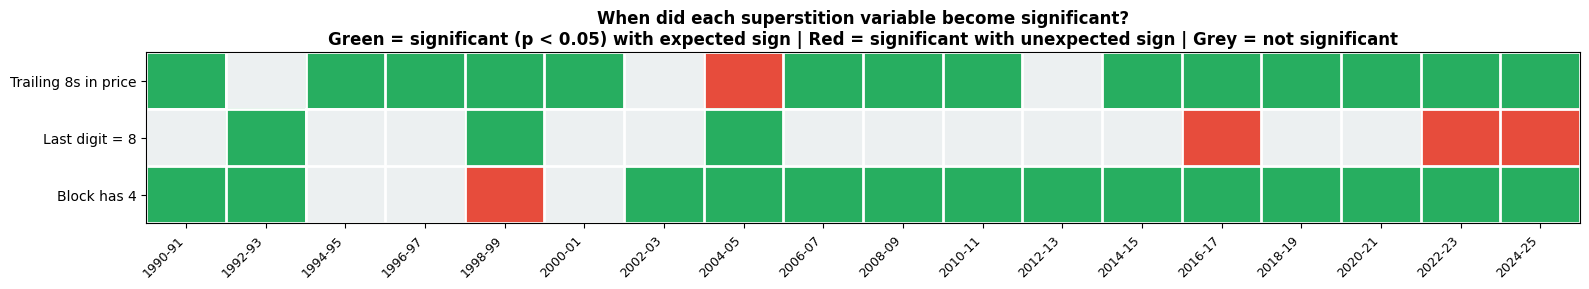

In [15]:
display_vars = ['num_eights_tail', 'ends_in_8', 'block_has_4']
expected_sign = {'num_eights_tail': 1, 'ends_in_8': 1, 'block_has_4': -1}
var_labels = {
    'num_eights_tail': 'Trailing 8s in price',
    'ends_in_8': 'Last digit = 8',
    'block_has_4': 'Block has 4',
}

fig, ax = plt.subplots(figsize=(16, 3))
matrix = np.zeros((len(display_vars), len(res)))
for j, (_, r) in enumerate(res.iterrows()):
    for i, var in enumerate(display_vars):
        coef = r.get(f'{var}_coef', np.nan)
        pval = r.get(f'{var}_pval', np.nan)
        if pd.isna(coef) or pd.isna(pval):
            matrix[i, j] = 0
        elif pval < 0.05:
            matrix[i, j] = 1 if np.sign(coef) == expected_sign[var] else -1

cmap = mcolors.ListedColormap(['#e74c3c', '#ecf0f1', '#27ae60'])
bounds = [-1.5, -0.5, 0.5, 1.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)
im = ax.imshow(matrix, cmap=cmap, norm=norm, aspect='auto')
ax.set_xticks(range(len(res)))
ax.set_xticklabels(res['period'], rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(display_vars)))
ax.set_yticklabels([var_labels[v] for v in display_vars], fontsize=10)
ax.set_title('When did each superstition variable become significant?\n'
             'Green = significant (p < 0.05) with expected sign | '
             'Red = significant with unexpected sign | '
             'Grey = not significant',
             fontsize=12, fontweight='bold')
for i in range(len(display_vars) + 1):
    ax.axhline(y=i - 0.5, color='white', linewidth=2)
for j in range(len(res) + 1):
    ax.axvline(x=j - 0.5, color='white', linewidth=2)

plt.tight_layout()
plt.savefig('data/superstition_significance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## The verdict: have Singaporeans become more superstitious?

In [16]:
print('=== SUMMARY ===')
print()

first_888 = prev.iloc[0]['pct_ends_888']
last_888 = prev.iloc[-1]['pct_ends_888']
print(f'888-ending prices: {first_888:.2f}% ({prev.iloc[0]["period"]}) \u2192 '
      f'{last_888:.2f}% ({prev.iloc[-1]["period"]})')

first_r = res.iloc[0]
last_r = res.iloc[-1]
for var, label in [('num_eights_tail', 'num_eights_tail'), ('block_has_4', 'block_has_4')]:
    print(f'\n{label} coefficient:')
    print(f'  {first_r["period"]}: ${first_r[f"{var}_coef"]:+,.0f} '
          f'({first_r[f"{var}_pct"]:+.2f}% of mean) '
          f'p={first_r[f"{var}_pval"]:.4f}')
    print(f'  {last_r["period"]}: ${last_r[f"{var}_coef"]:+,.0f} '
          f'({last_r[f"{var}_pct"]:+.2f}% of mean) '
          f'p={last_r[f"{var}_pval"]:.4f}')

print(f'\n\u0394R\u00b2 (superstition\u2019s explanatory power):')
print(f'  {delta.iloc[0]["period"]}: {delta.iloc[0]["delta_r2_pct"]:.4f}%  F={delta.iloc[0]["f_stat"]:.1f}')
print(f'  {delta.iloc[-1]["period"]}: {delta.iloc[-1]["delta_r2_pct"]:.4f}%  F={delta.iloc[-1]["f_stat"]:.1f}')

print(f'\n=== Significance count (out of {len(res)} windows) ===')
for var in display_vars:
    sig_count = (res[f'{var}_pval'] < 0.05).sum()
    print(f'  {var_labels[var]:25s}: significant in {sig_count}/{len(res)} windows')

=== SUMMARY ===

888-ending prices: 0.02% (1990-91) → 8.38% (2024-25)

num_eights_tail coefficient:
  1990-91: $+1,444 (+2.04% of mean) p=0.0000
  2024-25: $+4,430 (+0.70% of mean) p=0.0000

block_has_4 coefficient:
  1990-91: $-617 (-0.87% of mean) p=0.0012
  2024-25: $-13,249 (-2.10% of mean) p=0.0000

ΔR² (superstition’s explanatory power):
  1990-91: 0.0131%  F=13.4
  2024-25: 0.0973%  F=147.9

=== Significance count (out of 18 windows) ===
  Trailing 8s in price     : significant in 15/18 windows
  Last digit = 8           : significant in 6/18 windows
  Block has 4              : significant in 15/18 windows


## The 168 story: same number, different meaning

168 (一路发, "prosperity all the way") is one of the most auspicious number sequences in Chinese culture. But tracking it across 35 years reveals something unexpected: the number 168 appeared in HDB prices far more often in the early 2000s than it does today. The difference is *what it meant*.

In 2004-05, over 1% of all HDB transactions contained 168 in the price. But most of those were simply **$168,000** — a round price in the range where most flats sold. By 2012, prices had risen well past $200K and the 168 pattern nearly vanished (0.05%). Now it's re-emerging (0.19% in 2024-25) — but in a completely different form: sellers are deliberately embedding 168 in higher prices like $416,888 or $1,168,000.

The regression tells us whether 168 prices sell for more or less than the model predicts, controlling for everything else. But the coefficient means different things in different eras.

In [17]:
# 168 analysis: prevalence, composition, and regression over time

rows_168 = []
for start, end, label in windows:
    w = full[(full['year'] >= start) & (full['year'] <= end)].copy()
    if len(w) < 500:
        continue
    
    has_168 = w[w['price_has_168'] == 1]
    n_168 = len(has_168)
    
    # How many are exactly $168,000?
    n_exactly_168k = len(has_168[has_168['resale_price'] == 168000])
    # How many are in the $160K-$169K range (round-number territory)?
    n_round_range = len(has_168[(has_168['resale_price'] >= 160000) & (has_168['resale_price'] < 170000)])
    # The rest are deliberate 168 patterns at other price levels
    n_deliberate = n_168 - n_round_range
    
    pct_168 = (n_168 / len(w)) * 100 if len(w) > 0 else 0
    pct_exactly_168k = (n_exactly_168k / n_168) * 100 if n_168 > 0 else 0
    pct_round = (n_round_range / n_168) * 100 if n_168 > 0 else 0
    pct_deliberate = (n_deliberate / n_168) * 100 if n_168 > 0 else 0
    
    # Run regression with 168
    mc = w['flat_model'].value_counts()
    rare = mc[mc < 50].index
    w['flat_model_grouped'] = w['flat_model'].apply(lambda x: 'Other' if x in rare else x)
    
    f168 = (base_formula + ' + price_has_168')
    try:
        m168 = smf.ols(f168, data=w).fit(cov_type='HC1')
        coef_168 = m168.params.get('price_has_168', np.nan)
        se_168 = m168.bse.get('price_has_168', np.nan)
        p_168 = m168.pvalues.get('price_has_168', np.nan)
        pct_of_mean = (coef_168 / w['resale_price'].mean()) * 100
    except:
        coef_168 = se_168 = p_168 = pct_of_mean = np.nan
    
    rows_168.append({
        'period': label, 'midpoint': (start + end) / 2,
        'n': len(w), 'mean_price': w['resale_price'].mean(),
        'n_168': n_168, 'pct_168': pct_168,
        'n_exactly_168k': n_exactly_168k, 'pct_exactly_168k': pct_exactly_168k,
        'n_round': n_round_range, 'pct_round': pct_round,
        'n_deliberate': n_deliberate, 'pct_deliberate': pct_deliberate,
        'coef': coef_168, 'se': se_168, 'pval': p_168, 'pct_of_mean': pct_of_mean,
    })

r168 = pd.DataFrame(rows_168)

print('=== 168 in HDB prices: prevalence, composition, and regression coefficient ===')
print()
print(f'{"Period":>8s}  {"N(168)":>7s}  {"Prev%":>6s}  '
      f'{"=$168K":>7s}  {"Round":>6s}  {"Delib":>6s}  '
      f'{"Coeff ($)":>11s}  {"% mean":>8s}  {"p-val":>10s}')
print('-' * 90)
for _, r in r168.iterrows():
    sig = '*' if r['pval'] < 0.05 else ' '
    print(f'{r["period"]:>8s}  {r["n_168"]:>7,.0f}  {r["pct_168"]:>5.2f}%  '
          f'{r["pct_exactly_168k"]:>6.0f}%  {r["pct_round"]:>5.0f}%  {r["pct_deliberate"]:>5.0f}%  '
          f'{r["coef"]:>+10,.0f}{sig}  {r["pct_of_mean"]:>+7.2f}%  {r["pval"]:>10.4f}')

=== 168 in HDB prices: prevalence, composition, and regression coefficient ===

  Period   N(168)   Prev%   =$168K   Round   Delib    Coeff ($)    % mean       p-val
------------------------------------------------------------------------------------------
 1990-91       29   0.11%      83%     83%     17%     +16,787*   +23.69%      0.0000
 1992-93       82   0.25%      93%     96%      4%      +5,117*    +4.60%      0.0300
 1994-95      255   0.48%      92%     96%      4%      -4,666*    -2.42%      0.0000
 1996-97      386   0.58%      93%     96%      4%      -4,679*    -1.60%      0.0000
 1998-99      666   0.61%      88%     97%      3%      -2,946*    -1.16%      0.0000
 2000-01      457   0.63%      86%     94%      6%      -1,919*    -0.77%      0.0428
 2002-03      423   0.65%      85%     91%      9%      +2,108*    +0.90%      0.0437
 2004-05      638   1.08%      84%     95%      5%      -6,703*    -2.86%      0.0000
 2006-07      447   0.82%      88%     96%      4%     

/var/folders/7h/fxll2jhj3s9dl0hn4k_ff6v00000gn/T/ipykernel_40666/172287608.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


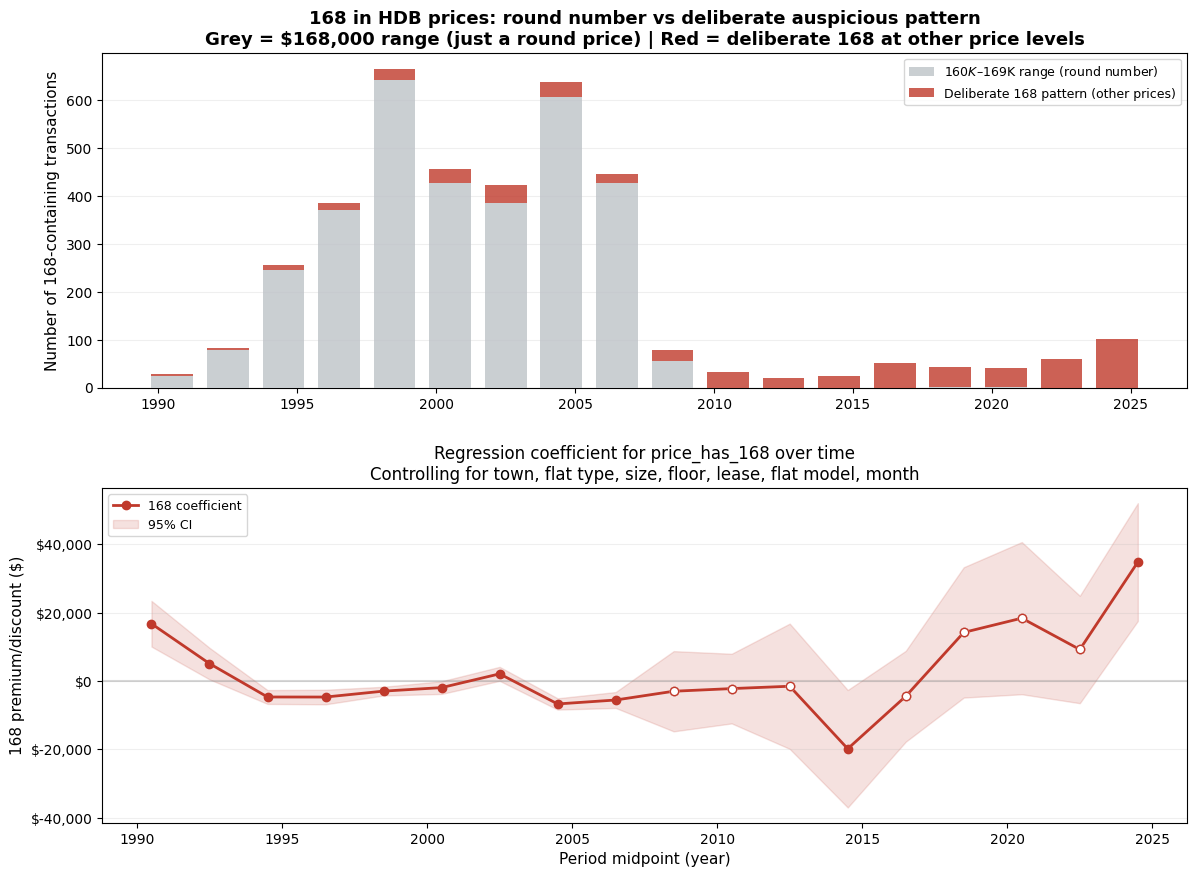

Open circles = not significant at p < 0.05


In [18]:
# Chart: 168 prevalence split by composition
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'hspace': 0.3})

# Panel 1: Stacked bar — round vs deliberate
width = 1.5
ax1.bar(r168['midpoint'], r168['n_round'], width=width, color='#bdc3c7',
        label='$160K–$169K range (round number)', alpha=0.8, zorder=3)
ax1.bar(r168['midpoint'], r168['n_deliberate'], width=width, bottom=r168['n_round'],
        color='#c0392b', label='Deliberate 168 pattern (other prices)', alpha=0.8, zorder=3)
ax1.set_ylabel('Number of 168-containing transactions', fontsize=11)
ax1.set_title('168 in HDB prices: round number vs deliberate auspicious pattern\n'
              'Grey = $168,000 range (just a round price) | Red = deliberate 168 at other price levels',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.2)

# Panel 2: Regression coefficient over time
ax2.plot(r168['midpoint'], r168['coef'], 'o-', color='#c0392b',
         linewidth=2, markersize=6, zorder=3, label='168 coefficient')
ax2.fill_between(r168['midpoint'],
                  r168['coef'] - 1.96 * r168['se'],
                  r168['coef'] + 1.96 * r168['se'],
                  alpha=0.15, color='#c0392b', label='95% CI')
ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax2.set_xlabel('Period midpoint (year)', fontsize=11)
ax2.set_ylabel('168 premium/discount ($)', fontsize=11)
ax2.set_title('Regression coefficient for price_has_168 over time\n'
              'Controlling for town, flat type, size, floor, lease, flat model, month',
              fontsize=12)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax2.grid(axis='y', alpha=0.2)
ax2.legend(loc='upper left', fontsize=9)

for _, r in r168.iterrows():
    if r['pval'] >= 0.05:
        ax2.plot(r['midpoint'], r['coef'], 'o',
                 color='white', markersize=6, zorder=4)
        ax2.plot(r['midpoint'], r['coef'], 'o',
                 color='#c0392b', markersize=6, zorder=4, markerfacecolor='none', linewidth=1.5)

plt.tight_layout()
plt.savefig('data/superstition_168_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Open circles = not significant at p < 0.05')

In [19]:
# Summary
early = r168[r168['midpoint'] <= 2005.5]
late = r168[r168['midpoint'] >= 2016.5]

print('=== 168 summary ===')
print()
print('EARLY PERIOD (1990–2005): 168 = a round price')
print(f'  Avg prevalence: {early["pct_168"].mean():.2f}%')
print(f'  Avg % that are exactly $168K or $160K–$169K range: {early["pct_round"].mean():.0f}%')
print(f'  Avg coefficient: ${early["coef"].mean():+,.0f}')
sig_early = (early['pval'] < 0.05).sum()
print(f'  Significant in {sig_early}/{len(early)} windows')

print()
print('LATE PERIOD (2016–2025): 168 = deliberate auspicious pattern')
print(f'  Avg prevalence: {late["pct_168"].mean():.2f}%')
print(f'  Avg % that are deliberate (not round-number range): {late["pct_deliberate"].mean():.0f}%')
print(f'  Avg coefficient: ${late["coef"].mean():+,.0f}')
sig_late = (late['pval'] < 0.05).sum()
print(f'  Significant in {sig_late}/{len(late)} windows')

=== 168 summary ===

EARLY PERIOD (1990–2005): 168 = a round price
  Avg prevalence: 0.55%
  Avg % that are exactly $168K or $160K–$169K range: 93%
  Avg coefficient: $+387
  Significant in 8/8 windows

LATE PERIOD (2016–2025): 168 = deliberate auspicious pattern
  Avg prevalence: 0.12%
  Avg % that are deliberate (not round-number range): 99%
  Avg coefficient: $+14,459
  Significant in 1/5 windows


## Caveats

1. **Price-digit artifact.** `num_eights_tail` counts 8s in the last 4 digits of the price. In the 1990s (5-digit prices), the \"last 4 digits\" includes the leading significant digit. The coefficient in early periods partly reflects round-number pricing ($88,000), not auspicious-digit signalling.

2. **No distance controls.** The historical model uses town fixed effects to absorb geography, but cannot include MRT distance, hawker proximity, or other distance variables (no geocoding for pre-2024 data).

3. **Historical model is simpler than Model 12.** Model 12 includes interaction terms (town × lease, town × storey, area × CBD distance) that absorb some variation attributed to superstition in simpler models. The coefficients here are not directly comparable to Model 12's +$1,710.

4. **Floor superstition variables excluded.** HDB data gives storey *ranges* (\"04 TO 06\", \"13 TO 15\"), not exact floor assignments. A flat in \"04 TO 06\" could be on floor 4, 5, or 6 — only a 1-in-3 chance of being on the superstitious floor. This makes any \"has_floor_4\" or \"has_floor_13\" variable too imprecise to test floor-level superstition. Exact unit-level data (which data.gov.sg does not provide) would be needed.

5. **Selection effects.** If increasingly superstitious buyers avoid block-4 flats, the remaining buyers in block-4 units are *less* superstitious — yet the discount still grows. This suggests the stigma has become market-wide.

### Note: feng shui distance variables (temple, columbarium, coast)

This notebook does NOT track feng shui proximity effects over time. The cross-sectional story is already told by Models 10-12 in the recent period. Extending to 35 years is technically feasible (97.3% of historical blocks can be geocoded) but the location reference files represent **current-day (2024-2026) infrastructure**, not historical positions. A future analysis could attempt this with appropriate caveats.